# Datos Masivos — McCain: ¿dónde se vende la papa industrial en México?

**Entregable 1** · Definición del problema, fuentes de datos y repositorio reproducible

Construimos dos extractores desde cero: uno con **scraping** (`requests` + `BeautifulSoup`)
y otro con **descarga automatizada** de CSV. Después los cruzamos y respondemos una
primera pregunta con datos.

**Pipeline de la fuente 1 (SNIIM):**

```text
Página web → requests → HTML → BeautifulSoup → registros → pandas → limpieza → CSV
```

**Pipeline de la fuente 2 (SIAP):**

```text
URL → CSV (latin-1) → pandas → normalizar esquema → tipos → CSV
```

Ejecutamos de arriba abajo. Usamos Python 3.9 o posterior y necesitamos internet.

## 0. Preparar el entorno

Detectamos si estamos en Colab, clonamos el repositorio si hace falta e instalamos
únicamente los paquetes que falten. Resolvemos las rutas a partir de la ubicación del
repositorio, **nunca desde una ruta personal**, para que el notebook corra igual en la
computadora de cualquiera de nosotros y en la del profesor.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

# --- 1. Si estamos en Colab, clonamos el repositorio --------------------------
REPO_URL = "https://github.com/0267601/datos-masivos-mccain-papa.git"
CARPETA_REPO = "datos-masivos-mccain-papa"

# Usamos try/except y no find_spec: find_spec("google.colab") lanza
# ModuleNotFoundError cuando el paquete padre "google" no existe, que es
# justo lo que pasa en un entorno virtual limpio.
try:
    import google.colab          # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB and not Path(CARPETA_REPO).exists():
    subprocess.check_call(["git", "clone", REPO_URL])

# --- 2. Instalamos solo lo que falte -----------------------------------------
requisitos = {
    "pandas": "pandas>=2,<3",
    "requests": "requests>=2.31,<3",
    "bs4": "beautifulsoup4>=4.12,<5",
    "matplotlib": "matplotlib>=3.7,<4",
    "pyarrow": "pyarrow>=14,<22",
}
faltantes = [paquete for modulo, paquete in requisitos.items()
             if importlib.util.find_spec(modulo) is None]
if faltantes:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltantes])

# --- 3. Localizamos la raíz del repositorio ----------------------------------
def encontrar_raiz():
    """Buscamos hacia arriba la carpeta que contiene src/sniim_extractor.py."""
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "sniim_extractor.py").exists():
            return candidata
        if (candidata / CARPETA_REPO / "src" / "sniim_extractor.py").exists():
            return candidata / CARPETA_REPO
    raise RuntimeError(
        "No encontramos la raíz del repositorio. "
        "Hay que ejecutar el notebook desde el repositorio clonado."
    )

RAIZ = encontrar_raiz()
DATOS = RAIZ / "data"
DATOS.mkdir(parents=True, exist_ok=True)

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

print("Entorno:", "Google Colab" if EN_COLAB else "Local")
print("Raíz del repositorio:", RAIZ.name + "/")
print("Carpeta de datos:", DATOS.relative_to(RAIZ.parent))

Entorno: Local
Raíz del repositorio: datos-masivos-mccain-papa/
Carpeta de datos: datos-masivos-mccain-papa/data


## 1. Importar librerías

In [2]:
import calendar
import json
import time
from datetime import date

import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("pandas:", pd.__version__)
print("Entorno listo")

Matplotlib is building the font cache; this may take a moment.


pandas: 2.3.3
Entorno listo


## 2. Definición del problema

McCain opera en México desde 1995 y su producto central es la papa procesada. Esa papa
requiere **variedad industrial** —tipo Russet o Alpha—, no papa de mesa genérica.

El problema que atacamos: las estadísticas públicas dicen **cuánto se produce**, pero no
**por qué canal se vende**. Un estado puede producir mucha papa y no ser un proveedor
disponible, porque su volumen ya está comprometido por contrato o porque su producción
se está extinguiendo.

### Pregunta

> ¿Qué estados mexicanos venden su papa fuera del mercado mayorista público, y cuáles
> de ellos están creciendo lo suficiente para sustituir importación de papa industrial?

### Usuario y decisión

**Usuario:** equipo de abasto agrícola y desarrollo de proveedores de una procesadora
de papa.

**Decisión:** a qué estados dirigir contratos agrícolas y programas de desarrollo de
proveedores, y en cuáles no invertir porque su producción está en contracción.

## 3. Fuentes de datos

| | Fuente 1 | Fuente 2 |
|---|---|---|
| Nombre | SNIIM — Precios de Mercados Nacionales | SIAP — Cierre de la Producción Agrícola |
| Institución | Secretaría de Economía | SADER |
| Variables | Fecha, variedad, presentación, origen, destino, precio mín/máx/frecuente | Superficie, volumen, rendimiento, precio medio rural, valor de producción |
| Periodo | 2010–2025, diario | 2003–2025, anual |
| Formato | **HTML** | **CSV (latin-1)** |
| Obtención | **Scraping con BeautifulSoup** | **Descarga automatizada** |

Obtenemos las dos por código y ninguna nos pide credenciales.

# 4. Fuente 1 — SNIIM con BeautifulSoup

Construimos el scraper paso a paso antes de empaquetarlo.

## 4.1 Primera petición HTTP

El SNIIM no tiene API: la consulta se manda por parámetros en la URL y responde HTML.

In [3]:
URL_CONSULTA = (
    "http://www.economia-sniim.gob.mx/nuevo/Consultas/MercadosNacionales/"
    "PreciosDeMercado/Agricolas/ResultadosConsultaFechaFrutasYHortalizas.aspx"
)

# Pedimos marzo de 2025 para la papa Alpha (ProductoId 740).
params = {
    "fechaInicio": "01/03/2025",
    "fechaFinal": "31/03/2025",
    "ProductoId": 740,
    "OrigenId": -1,
    "Origen": "Todos",
    "DestinoId": -1,
    "Destino": "Todos",
    "PreciosPorId": 2,
    "RegistrosPorPagina": 1000,
}

response = requests.get(URL_CONSULTA, params=params, timeout=90)
response.encoding = "utf-8"          # si lo dejamos adivinar, los acentos se rompen
response.raise_for_status()

print("Status code:", response.status_code)
print("Tamaño del HTML:", f"{len(response.text) / 1024:.0f} KB")

Status code: 200
Tamaño del HTML: 567 KB


Recordatorio de códigos: `200` éxito, `403` prohibido, `404` no encontrado,
`429` demasiadas solicitudes, `500` error del servidor.

A diferencia de una API, aquí no recibimos JSON sino una página pensada para humanos.

In [4]:
print(response.text[:600])


<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.0 Transitional//EN">
<HTML>
	<HEAD>
		<title>ResultadosConsultaFechaFrutasYHortalizas</title>
		<meta content="Microsoft Visual Studio .NET 7.1" name="GENERATOR">
		<meta content="Visual Basic .NET 7.1" name="CODE_LANGUAGE">
		<meta content="JavaScript" name="vs_defaultClientScript">
		<meta content="http://schemas.microsoft.com/intellisense/ie5" name="vs_targetSchema">
		<LINK href="../../../../Diseno/Estilos/estilo.css" type="text/css" rel="stylesheet">
	</HEAD>
	<body bottomMargin="0" leftMargin="0" topMargin="0" rightMargin="0" MS_POSIT


## 4.2 Interpretar el HTML con BeautifulSoup

In [5]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title)
print(soup.title.text.strip()[:80])

<title>ResultadosConsultaFechaFrutasYHortalizas</title>
ResultadosConsultaFechaFrutasYHortalizas


## 4.3 Encontrar la tabla de datos

La página trae **nueve** tablas: unas son de diseño, otras de encabezados. Necesitamos
identificar cuál tiene los precios.

In [6]:
todas_las_tablas = soup.find_all("table")
print("Tablas en la página:", len(todas_las_tablas))

for tabla in todas_las_tablas:
    print(f"  id={tabla.get('id')!r:28s} filas={len(tabla.find_all('tr'))}")

Tablas en la página: 14
  id='Table1'                     filas=830
  id='tblPrincipal'               filas=6
  id='tblEncabezadoMercado'       filas=1
  id='tblTituloModulo'            filas=1
  id='tblPeriodicidad'            filas=3
  id=None                         filas=2
  id='Table2'                     filas=810
  id='tblDatosGenerales'          filas=7
  id='tblResultados'              filas=794
  id=None                         filas=4
  id=None                         filas=4
  id=None                         filas=1
  id='Table1'                     filas=3
  id=None                         filas=1


La tabla con los precios es `tblResultados`. Al tener un `id` propio, podemos usar un
selector CSS en lugar de adivinar por tamaño, que sería frágil.

In [7]:
tabla = soup.select_one("table#tblResultados")

filas = tabla.select("tr")
print("Filas en tblResultados:", len(filas))

# La primera fila es el encabezado.
encabezados = [celda.text.strip() for celda in filas[0].find_all(["td", "th"])]
print("Encabezados:", encabezados)

Filas en tblResultados: 794
Encabezados: ['Fecha', 'Presentación', 'Origen', 'Destino', 'Precio Mín', 'Precio Max', 'Precio Frec', 'Obs.']


## 4.4 Inspeccionar una fila de datos

In [8]:
primera_fila = filas[2]          # 0 y 1 son encabezados
print(primera_fila.prettify())

<tr>
 <td class="Datos2" colspan="1">
  03/03/2025
 </td>
 <td class="Datos2">
  Kilogramo
 </td>
 <td class="Datos2">
  México
 </td>
 <td class="Datos2">
  Aguascalientes: Centro Comercial Agropecuario de Aguascalientes
 </td>
 <td class="Datos2">
  19.00
 </td>
 <td class="Datos2">
  23.00
 </td>
 <td class="Datos2">
  21.00
 </td>
 <td class="Datos2">
 </td>
</tr>



Cada celda lleva `class="Datos2"`. Comprobamos que **todas** las filas de datos usan la
misma clase: si alternaran clases, el selector nos perdería la mitad de los registros.

In [9]:
con_ocho_celdas = sum(1 for f in filas if len(f.select("td.Datos2")) == 8)

print("Filas con 8 celdas 'Datos2':", con_ocho_celdas)
print("Celdas 'td.Datos2' en total:", len(tabla.select("td.Datos2")))
print("Celdas 'td' en total       :", len(tabla.find_all("td")))
print("Consistente:", con_ocho_celdas * 8 == len(tabla.select("td.Datos2")))

Filas con 8 celdas 'Datos2': 792
Celdas 'td.Datos2' en total: 6336
Celdas 'td' en total       : 6345
Consistente: True


## 4.5 Extraer un registro

In [10]:
celdas = primera_fila.select("td.Datos2")

fecha = celdas[0].text.strip()
presentacion = celdas[1].text.strip()
origen = celdas[2].text.strip()
destino = celdas[3].text.strip()
precio_frec = celdas[6].text.strip()

print("Fecha:", fecha)
print("Presentación:", presentacion)
print("Origen:", origen)
print("Destino:", destino)
print("Precio frecuente:", precio_frec)

Fecha: 03/03/2025
Presentación: Kilogramo
Origen: México
Destino: Aguascalientes: Centro Comercial Agropecuario de Aguascalientes
Precio frecuente: 21.00


## 4.6 Extracción segura

Si una celda desaparece, `.text` truena con `AttributeError`. Usamos un helper que
devuelve `None` en lugar de fallar.

In [11]:
def texto_seguro(elemento):
    """Devolvemos el texto de un elemento, o None si no existe."""
    if elemento is None:
        return None
    return elemento.text.strip()


print(texto_seguro(primera_fila.select_one("td.Datos2")))
print(texto_seguro(primera_fila.select_one("td.NoExiste")))

03/03/2025
None


## 4.7 Construir un registro

In [12]:
CAMPOS = ["fecha", "presentacion", "origen", "destino",
          "precio_min", "precio_max", "precio_frec", "obs"]

registro = {campo: texto_seguro(celda) for campo, celda in zip(CAMPOS, celdas)}
registro["variedad"] = "Alpha"

registro

{'fecha': '03/03/2025',
 'presentacion': 'Kilogramo',
 'origen': 'México',
 'destino': 'Aguascalientes: Centro Comercial Agropecuario de Aguascalientes',
 'precio_min': '19.00',
 'precio_max': '23.00',
 'precio_frec': '21.00',
 'obs': '',
 'variedad': 'Alpha'}

## 4.8 Extraer todos los registros de la página

In [13]:
resultados = []

for fila in tabla.select("tr"):
    celdas = fila.select("td.Datos2")

    # Saltamos encabezados y filas incompletas.
    if len(celdas) != len(CAMPOS):
        continue

    registro = {campo: texto_seguro(celda) for campo, celda in zip(CAMPOS, celdas)}
    registro["variedad"] = "Alpha"
    resultados.append(registro)

print("Registros:", len(resultados))
resultados[:2]

Registros: 792


[{'fecha': '03/03/2025',
  'presentacion': 'Kilogramo',
  'origen': 'México',
  'destino': 'Aguascalientes: Centro Comercial Agropecuario de Aguascalientes',
  'precio_min': '19.00',
  'precio_max': '23.00',
  'precio_frec': '21.00',
  'obs': '',
  'variedad': 'Alpha'},
 {'fecha': '03/03/2025',
  'presentacion': 'Kilogramo',
  'origen': 'Michoacán',
  'destino': 'Aguascalientes: Centro Comercial Agropecuario de Aguascalientes',
  'precio_min': '21.00',
  'precio_max': '25.00',
  'precio_frec': '23.00',
  'obs': '',
  'variedad': 'Alpha'}]

## 4.9 Convertir a DataFrame

In [14]:
df_marzo = pd.DataFrame(resultados)

print(df_marzo.shape)
df_marzo.info()

(792, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fecha         792 non-null    object
 1   presentacion  792 non-null    object
 2   origen        792 non-null    object
 3   destino       792 non-null    object
 4   precio_min    792 non-null    object
 5   precio_max    792 non-null    object
 6   precio_frec   792 non-null    object
 7   obs           792 non-null    object
 8   variedad      792 non-null    object
dtypes: object(9)
memory usage: 55.8+ KB


## 4.10 Limpieza

Todo llega como texto. Convertimos fechas y precios, y derivamos dos columnas que
usamos más adelante: el estado del mercado destino y si el origen es importación.

In [15]:
def limpiar(df):
    """Asignamos tipos y derivamos las dos columnas que usamos después."""
    df = df.copy()

    df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y", errors="coerce")

    for columna in ["precio_min", "precio_max", "precio_frec"]:
        df[columna] = pd.to_numeric(df[columna], errors="coerce")

    # El destino viene como "Estado: Nombre del mercado". Separamos el estado.
    df["estado_destino"] = df["destino"].str.split(":").str[0].str.strip()

    # Marcamos la papa importada: es la distinción central de nuestro análisis.
    df["es_importacion"] = df["origen"].eq("Importación")

    return df.dropna(subset=["fecha"]).reset_index(drop=True)


df_marzo = limpiar(df_marzo)

display(df_marzo[["fecha", "origen", "estado_destino", "precio_frec", "es_importacion"]].head())
display(pd.DataFrame({"tipo": df_marzo.dtypes.astype(str),
                      "faltantes": df_marzo.isna().sum()}))

,fecha,origen,estado_destino,precio_frec,es_importacion
0,2025-03-03,México,Aguascalientes,21.0,False
1,2025-03-03,Michoacán,Aguascalientes,23.0,False
2,2025-03-04,México,Aguascalientes,21.0,False
3,2025-03-04,Michoacán,Aguascalientes,23.0,False
4,2025-03-05,México,Aguascalientes,16.0,False


,tipo,faltantes
fecha,datetime64[ns],0
presentacion,object,0
origen,object,0
destino,object,0
precio_min,float64,0
precio_max,float64,0
precio_frec,float64,0
obs,object,0
variedad,object,0
estado_destino,object,0


# 5. El límite del SNIIM y el particionamiento

Ya sabemos raspar **una** página. El problema aparece al pedir un periodo grande.

SNIIM corta cada consulta a **1000 registros y no nos avisa que truncó**. Es el mismo
problema de escala que el límite de una API: si pedimos un año completo recibimos 1000
filas que *parecen* correctas.

Primero comprobamos que el problema es real.

In [16]:
LIMITE = 1000

# Pedimos el año completo de una sola vez: la forma ingenua.
params_anual = dict(params, fechaInicio="01/01/2025", fechaFinal="31/12/2025")

response_anual = requests.get(URL_CONSULTA, params=params_anual, timeout=120)
response_anual.encoding = "utf-8"
response_anual.raise_for_status()

soup_anual = BeautifulSoup(response_anual.text, "html.parser")
tabla_anual = soup_anual.select_one("table#tblResultados")
filas_anual = sum(1 for f in tabla_anual.select("tr") if len(f.select("td.Datos2")) == 8)

print("Papa Alpha 2025, consulta anual de una sola vez:", f"{filas_anual:,} registros")
print("¿Tocó el límite?", filas_anual >= LIMITE - 2)

Papa Alpha 2025, consulta anual de una sola vez: 1,000 registros
¿Tocó el límite? True


## 5.1 Una función por partición

Aplicamos la misma solución que con el particionamiento de una API: **dividimos la
consulta por periodo**. Aquí partimos por mes.

Empaquetamos el scraper en `src/sniim_extractor.py` para reutilizarlo, con las mismas
funciones que acabamos de construir a mano: `texto_seguro`, el selector
`table#tblResultados`, las celdas `td.Datos2` y `limpiar`.

In [17]:
from src.sniim_extractor import (
    VARIEDADES_PAPA,
    extraer_precios_mes,
    descargar_periodo,
)

print("Variedades en el catálogo del SNIIM:", VARIEDADES_PAPA)

# Comprobamos que la función empaquetada da el mismo resultado que el código a mano.
registros_mes, bytes_html = extraer_precios_mes(740, 2025, 3)

print()
print("A mano en la sección 4 :", len(resultados), "registros")
print("Con la función de src/ :", len(registros_mes), "registros")
print("Coinciden:", len(resultados) == len(registros_mes))

Variedades en el catálogo del SNIIM: {740: 'Alpha', 748: 'Galeana', 749: 'Gema', 753: 'Marciana', 766: 'Rouset', 767: 'San Jose'}



A mano en la sección 4 : 792 registros
Con la función de src/ : 792 registros
Coinciden: True


## 5.2 Recorrer varias particiones

Igual que al recorrer varias páginas en la práctica de scraping, iteramos las
particiones y **esperamos un segundo entre peticiones**. No es opcional: sin la pausa
podemos saturar el servidor. De hecho nos pasó: al correr las 72 peticiones seguidas
el SNIIM empezó a devolver `503 Service Unavailable` de forma intermitente. Por eso
`descargar_pagina` reintenta con espera creciente antes de rendirse.

Lo probamos con tres meses antes de lanzar las 72 peticiones.

In [18]:
prueba = []

for mes in range(1, 4):
    registros_mes, bytes_html = extraer_precios_mes(740, 2025, mes)

    print(f"Descargando 2025-{mes:02d}:",
          f"{len(registros_mes):5,} filas",
          f"| HTML {bytes_html / 1024**2:.2f} MB")

    prueba.extend(registros_mes)

    time.sleep(1)          # cortesía con el servidor

print()
print("Total de los tres meses:", f"{len(prueba):,} registros")

Descargando 2025-01:   837 filas | HTML 0.58 MB


Descargando 2025-02:   749 filas | HTML 0.52 MB


Descargando 2025-03:   792 filas | HTML 0.55 MB



Total de los tres meses: 2,378 registros


## 5.3 Recorrer todas las particiones

Hacemos 72 peticiones (6 variedades x 12 meses), con una pausa entre cada una para no
saturar el servidor. Tardamos **2–3 minutos**.

De cada partición guardamos filas, tamaño del HTML y una bandera `truncado`. Si alguna
siguiera tocando el límite, tendríamos que partir por quincena.

In [19]:
ANIOS_SNIIM = [2025]

sniim, metricas_sniim = descargar_periodo(
    producto_ids=list(VARIEDADES_PAPA),
    anios=ANIOS_SNIIM,
    pausa=0.3,
    verbose=False,
)

print(f"Registros obtenidos: {len(sniim):,}")
print(f"Particiones descargadas: {len(metricas_sniim)}")
print(f"Particiones truncadas: {int(metricas_sniim['truncado'].sum())}")
print()

alpha = int(metricas_sniim.loc[metricas_sniim.variedad == "Alpha", "filas"].sum())
print("Comparación para Papa Alpha 2025:")
print(f"  consulta anual ingenua : {filas_anual:,} registros")
print(f"  particionada por mes   : {alpha:,} registros")
print(f"  se habrían perdido     : {100 * (1 - filas_anual / alpha):.1f}% de los datos")

Registros obtenidos: 11,010
Particiones descargadas: 72
Particiones truncadas: 0

Comparación para Papa Alpha 2025:
  consulta anual ingenua : 1,000 registros
  particionada por mes   : 9,757 registros
  se habrían perdido     : 89.8% de los datos


In [20]:
metricas_sniim.groupby("variedad").agg(
    particiones=("filas", "size"),
    filas=("filas", "sum"),
    html_mb=("html_mb", "sum"),
    truncadas=("truncado", "sum"),
).round(2)

,particiones,filas,html_mb,truncadas
variedad,,,,
Alpha,12,9757,6.81,0
Galeana,12,496,0.51,0
Gema,12,253,0.32,0
Marciana,12,0,0.11,0
Rouset,12,251,0.33,0
San Jose,12,253,0.32,0


## 5.4 Duplicados en los límites de las particiones

Al partir por periodo conviene revisar que no se repitan registros en las fronteras.

In [21]:
llave_sniim = ["fecha", "variedad", "origen", "destino", "presentacion"]
duplicados = sniim.duplicated(subset=llave_sniim).sum()

print("Duplicados encontrados:", duplicados)
print(f"Filas: {len(sniim):,}")

Duplicados encontrados: 0
Filas: 11,010


# 6. Fuente 2 — SIAP por descarga automatizada

Aquí no hay HTML que raspar: el portal sirve un CSV por año con **todos** los cultivos.
Descargamos y filtramos papa.

Tres problemas de calidad que corregimos en `src/siap_extractor.py`:

1. Los **encabezados cambian entre años**: `Nomcultivo` → `Nomcultivo Sin Um` (2016–2019),
   y `Precio` → `Preciomediorural` (2021 en adelante). Concatenar sin normalizar truena.
2. El archivo viene en **latin-1**, no en utf-8.
3. Las **columnas numéricas llegan como texto** en algunos años: otros cultivos del mismo
   CSV traen valores no numéricos y pandas infiere `object` para toda la columna.

In [22]:
from src.siap_extractor import descargar_anios

ANIOS_SIAP = range(2013, 2026)

siap, metricas_siap = descargar_anios(ANIOS_SIAP, cultivo="papa", pausa=0.3, verbose=False)

print(f"Filas de papa: {len(siap):,}")
print(f"Años: {siap.Anio.min()}–{siap.Anio.max()}")
print(f"Total descargado: {metricas_siap.descarga_mb.sum():.0f} MB")
print(f"En memoria tras filtrar: {metricas_siap.ram_mb.sum():.2f} MB")
metricas_siap.round(2)

Filas de papa: 3,171
Años: 2013–2025
Total descargado: 72 MB
En memoria tras filtrar: 1.49 MB


,anio,filas_papa,descarga_mb,ram_mb
0,2013,237,6.01,0.11
1,2014,249,5.97,0.12
2,2015,240,5.67,0.11
3,2016,249,5.60,0.12
4,2017,242,5.61,0.11
5,2018,249,5.59,0.12
6,2019,244,5.64,0.11
7,2020,241,4.42,0.11
8,2021,238,4.43,0.11
9,2022,249,5.75,0.12


Descargamos 72 MB para quedarnos con 1.5 MB. La diferencia vale la pena verla: el costo
de transferencia no tiene nada que ver con el costo en memoria.

# 7. Primera extracción

Revisamos primeras filas, dimensiones y tipos de cada fuente.

In [23]:
print("=" * 70)
print("SNIIM — precios de venta")
print("=" * 70)
print("Dimensiones:", sniim.shape)
display(sniim.head())
display(pd.DataFrame({"tipo": sniim.dtypes.astype(str),
                      "faltantes": sniim.isna().sum()}))

SNIIM — precios de venta
Dimensiones: (11010, 11)


,fecha,presentacion,origen,destino,precio_min,precio_max,precio_frec,obs,variedad,estado_destino,es_importacion
0,2025-01-02,Kilogramo,México,Aguascalientes: Centro Comercial Agropecuario ...,18.0,20.0,19.0,,Alpha,Aguascalientes,False
1,2025-01-02,Kilogramo,Michoacán,Aguascalientes: Centro Comercial Agropecuario ...,21.0,25.0,23.0,,Alpha,Aguascalientes,False
2,2025-01-03,Kilogramo,México,Aguascalientes: Centro Comercial Agropecuario ...,18.0,20.0,19.0,,Alpha,Aguascalientes,False
3,2025-01-03,Kilogramo,Michoacán,Aguascalientes: Centro Comercial Agropecuario ...,21.0,25.0,23.0,,Alpha,Aguascalientes,False
4,2025-01-06,Kilogramo,México,Aguascalientes: Centro Comercial Agropecuario ...,18.0,20.0,19.0,,Alpha,Aguascalientes,False


,tipo,faltantes
fecha,datetime64[ns],0
presentacion,object,0
origen,object,0
destino,object,0
precio_min,float64,0
precio_max,float64,0
precio_frec,float64,0
obs,object,0
variedad,object,0
estado_destino,object,0


In [24]:
print("=" * 70)
print("SIAP — producción y valor de venta")
print("=" * 70)
print("Dimensiones:", siap.shape)
display(siap.head())
display(pd.DataFrame({"tipo": siap.dtypes.astype(str),
                      "faltantes": siap.isna().sum()}))

SIAP — producción y valor de venta
Dimensiones: (3171, 15)


,Anio,Nomestado,Nomddr,Nomcader,Nommunicipio,Nomcicloproductivo,Nommodalidad,Nomcultivo,Sembrada,Cosechada,Siniestrada,Volumenproduccion,Rendimiento,Preciomediorural,Valorproduccion
0,2013,Baja California,Ensenada,Ensenada,Ensenada,Primavera-Verano,Riego,Papa,26.0,26.0,0.0,470.08,18.08,4425.53,2.080353e+06
1,2013,Baja California Sur,Comondú,Comondú,Comondú,Otoño-Invierno,Riego,Papa,1200.0,1016.0,184.0,25806.40,25.40,4217.57,1.088403e+08
2,2013,Baja California Sur,Comondú,Comondú,Comondú,Primavera-Verano,Riego,Papa,1060.0,1060.0,0.0,37100.00,35.00,5839.62,2.166499e+08
3,2013,Coahuila,Frontera,Ocampo,Ocampo,Primavera-Verano,Riego,Papa,235.0,235.0,0.0,9400.00,40.00,5250.00,4.935000e+07
4,2013,Coahuila,Saltillo,Arteaga,Arteaga,Primavera-Verano,Riego,Papa,122.0,122.0,0.0,4607.94,37.77,6662.20,3.069902e+07


,tipo,faltantes
Anio,int64,0
Nomestado,object,0
Nomddr,object,0
Nomcader,object,0
Nommunicipio,object,0
Nomcicloproductivo,object,0
Nommodalidad,object,0
Nomcultivo,object,0
Sembrada,float64,0
Cosechada,float64,0


# 8. Diagnóstico inicial

Revisamos valores faltantes, duplicados e inconsistencias, y anotamos qué
transformaciones vamos a necesitar después.

In [25]:
print("--- Faltantes ---")
print("SNIIM:", sniim.isna().sum().loc[lambda s: s > 0].to_dict() or "ninguno relevante")
print("SIAP :", siap.isna().sum().loc[lambda s: s > 0].to_dict() or "ninguno relevante")

print()
print("--- Duplicados ---")
print(f"SNIIM (por {llave_sniim}): {sniim.duplicated(subset=llave_sniim).sum()}")

llave_siap = ["Anio", "Nomestado", "Nomddr", "Nomcader", "Nommunicipio",
              "Nomcicloproductivo", "Nommodalidad"]
print(f"SIAP  (llave completa, {len(llave_siap)} columnas): "
      f"{siap.duplicated(subset=llave_siap).sum()}")

# Comprobamos que sin Nomddr ni Nomcader la llave NO es única: SIAP desagrega
# por debajo del municipio y nos aparecen falsos duplicados.
llave_corta = ["Anio", "Nomestado", "Nommunicipio", "Nomcicloproductivo", "Nommodalidad"]
print(f"SIAP  (llave sin DDR/CADER): {siap.duplicated(subset=llave_corta).sum()}"
      "  <- falsos duplicados")

print()
print("--- Consistencia interna de SIAP ---")
print("Filas con cosechada > sembrada (imposible):",
      int((siap.Cosechada > siap.Sembrada).sum()))
print("Filas cosechadas con volumen cero:",
      int(((siap.Cosechada > 0) & (siap.Volumenproduccion == 0)).sum()))

print()
print("--- Rango de precios SNIIM ---")
print(sniim.groupby("variedad")["precio_frec"].describe()[["min", "50%", "max"]].round(2))

--- Faltantes ---
SNIIM: ninguno relevante
SIAP : ninguno relevante

--- Duplicados ---
SNIIM (por ['fecha', 'variedad', 'origen', 'destino', 'presentacion']): 0
SIAP  (llave completa, 7 columnas): 0
SIAP  (llave sin DDR/CADER): 186  <- falsos duplicados

--- Consistencia interna de SIAP ---
Filas con cosechada > sembrada (imposible): 0
Filas cosechadas con volumen cero: 0

--- Rango de precios SNIIM ---
            min    50%    max
variedad                     
Alpha      0.43  18.00  35.00
Galeana   10.00  12.00  20.00
Gema      15.00  15.00  15.00
Rouset     7.73   9.09  15.23
San Jose  12.00  20.00  28.00


### Problemas identificados y transformaciones necesarias

| Problema | Detectado en | Transformación requerida |
|---|---|---|
| SNIIM trunca a 1000 registros sin avisar | Sección 5 | Particionar la consulta por mes. **Ya aplicado.** |
| SNIIM devuelve `503` de forma intermitente | Sección 5.3 | Reintentar con espera creciente (3 s, 6 s, 9 s) y pausar 1 s entre peticiones. **Ya aplicado.** |
| `find_spec("google.colab")` truena en un entorno limpio | Sección 0 | Detectar Colab con `try/except ImportError`, no con `find_spec`. **Ya aplicado.** |
| La página trae 9 tablas, unas de diseño | Sección 4.3 | Seleccionar por `id` (`table#tblResultados`), no por tamaño. **Ya aplicado.** |
| Todo el HTML llega como texto | Sección 4.10 | `pd.to_datetime` y `pd.to_numeric`. **Ya aplicado.** |
| SIAP cambia encabezados entre años | `src/siap_extractor.py` | Renombrar `Nomcultivo Sin Um` y `Precio`. **Ya aplicado.** |
| SIAP viene en latin-1, SNIIM en utf-8 | Ambos extractores | Fijar la codificación explícitamente. **Ya aplicado.** |
| Columnas numéricas de SIAP llegan como texto | Sección 7 | `pd.to_numeric` tras filtrar por cultivo. **Ya aplicado.** |
| SIAP desagrega por debajo del municipio | Sección 8 | Conservar `Nomddr` y `Nomcader`. **Ya aplicado.** |
| `origen` en SNIIM es el origen *declarado*, no el estado productor | Sección 10 | Las centrales de abasto redistribuyen. **Pendiente de ajuste.** |
| SIAP no distingue variedad de papa | Sección 7 | Cruzar con SNIIM, que sí separa las seis variedades. |
| Nombres de estado difieren entre fuentes | Sección 10 | Mapear `Ciudad de México` ↔ `Distrito Federal`. **Pendiente de ampliar.** |
| Precio frecuente tiene valores atípicos muy bajos | Sección 8 | Revisar outliers antes de promediar en el entregable 2. |

# 9. Primera evidencia

Respondemos una pregunta sencilla: **¿qué variedad de papa es importada?**

In [26]:
evidencia = sniim.groupby("variedad").apply(
    lambda g: pd.Series({
        "registros": len(g),
        "% importada": 100 * g["es_importacion"].mean(),
        "precio $/kg": g["precio_frec"].mean(),
        "mercados": g["destino"].nunique(),
        "estados origen": g.loc[~g["es_importacion"], "origen"].nunique(),
    }),
    include_groups=False,
).sort_values("% importada", ascending=False).round(2)

display(evidencia)

,registros,% importada,precio $/kg,mercados,estados origen
variedad,,,,,
Rouset,251.0,99.6,9.87,1.0,1.0
Alpha,9757.0,3.6,18.85,43.0,17.0
Galeana,496.0,0.0,12.32,2.0,1.0
Gema,253.0,0.0,15.00,2.0,1.0
San Jose,253.0,0.0,18.62,2.0,1.0


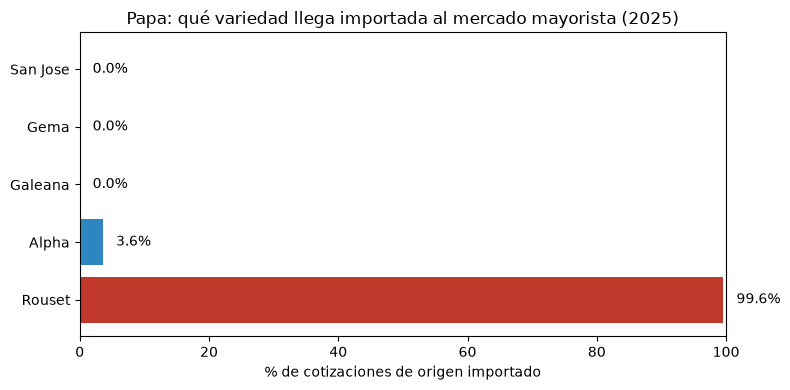

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#c0392b" if v > 50 else "#2e86c1" for v in evidencia["% importada"]]
ax.barh(evidencia.index, evidencia["% importada"], color=colores)
ax.set_xlabel("% de cotizaciones de origen importado")
ax.set_title("Papa: qué variedad llega importada al mercado mayorista (2025)")
ax.set_xlim(0, 100)
for y, v in enumerate(evidencia["% importada"]):
    ax.text(v + 2, y, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

### Interpretación

**La variedad Rouset (Russet) es 99.6% importada.** Es la única variedad industrial del
catálogo del SNIIM —la que se ocupa para papa a la francesa— y prácticamente no tiene
oferta nacional visible: de sus cotizaciones en 2025, solo una fue de origen mexicano.

Tres detalles refuerzan la lectura:

1. Se cotiza en **un solo mercado**, la Central de Abasto de Tijuana: entra por la
   frontera y se queda en la frontera.
2. Se vende en **arpilla de 22 kg**, presentación industrial, mientras la papa de mesa
   se cotiza por kilogramo.
3. Cuesta **cerca de la mitad** que la Alpha nacional.

Es decir: el insumo industrial importado es más barato que la papa nacional de mesa.
Cualquier estrategia de sustitución de importación parte en desventaja de costo, y por
eso importa saber qué estados tienen producción todavía no comprometida.

In [28]:
# Confirmamos los tres detalles con los datos, no de memoria.
russet = sniim[sniim.variedad == "Rouset"]

print("Orígenes de la Russet:", russet.origen.value_counts().to_dict())
print("Mercados donde se cotiza:", russet.destino.unique().tolist())
print("Presentación:", russet.presentacion.unique().tolist())
print(f"Precio Russet: ${russet.precio_frec.mean():.2f}/kg")
print(f"Precio Alpha : ${sniim.loc[sniim.variedad == 'Alpha', 'precio_frec'].mean():.2f}/kg")

Orígenes de la Russet: {'Importación': 250, 'Jalisco': 1}
Mercados donde se cotiza: ['Baja California : Central de Abasto INDIA, Tijuana']
Presentación: ['Arpilla de 22 kg.']
Precio Russet: $9.87/kg
Precio Alpha : $18.85/kg


# 10. Cruce de las dos fuentes: índice de canalización

Construimos un indicador que compara el peso de un estado en la producción nacional
contra su peso en el mercado mayorista público.

In [29]:
MAPA_ESTADOS = {"Ciudad de México": "Distrito Federal"}

ultimo = siap.Anio.max()
produccion = (siap[siap.Anio == ultimo]
              .assign(estado=lambda d: d.Nomestado.map(lambda e: MAPA_ESTADOS.get(e, e)))
              .groupby("estado")
              .agg(ton=("Volumenproduccion", "sum"), valor=("Valorproduccion", "sum")))
produccion["% produccion"] = 100 * produccion.ton / produccion.ton.sum()

nacional = sniim[~sniim.es_importacion]
presencia = (nacional.origen.value_counts(normalize=True) * 100).rename("% mayoreo")

canal = produccion.join(presencia).fillna({"% mayoreo": 0})
canal["canalizacion"] = canal["% produccion"] - canal["% mayoreo"]
canal["$/ton"] = canal.valor / canal.ton
canal = canal[canal.ton > 5000].sort_values("canalizacion", ascending=False)

display(canal[["ton", "% produccion", "% mayoreo", "canalizacion", "$/ton"]].round(1))

,ton,% produccion,% mayoreo,canalizacion,$/ton
estado,,,,,
Sonora,687679.1,30.8,2.6,28.1,8278.3
Sinaloa,605742.0,27.1,24.0,3.1,7868.2
Nuevo León,112310.0,5.0,2.3,2.7,13596.7
Baja California Sur,48910.0,2.2,0.0,2.2,6260.3
Chiapas,28764.7,1.3,0.0,1.3,8766.8
Guanajuato,27573.2,1.2,0.0,1.2,10669.2
Chihuahua,22884.9,1.0,0.0,1.0,10262.8
Michoacán,56389.9,2.5,1.5,1.0,8351.3
Tlaxcala,8184.1,0.4,0.1,0.3,8363.0


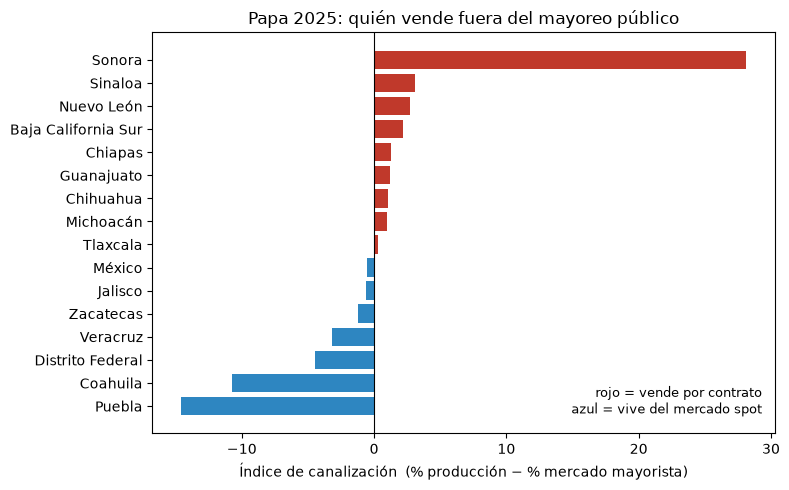

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
orden = canal.sort_values("canalizacion")
colores = ["#c0392b" if v > 0 else "#2e86c1" for v in orden.canalizacion]
ax.barh(orden.index, orden.canalizacion, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Índice de canalización  (% producción − % mercado mayorista)")
ax.set_title(f"Papa {ultimo}: quién vende fuera del mayoreo público")
ax.text(0.98, 0.05, "rojo = vende por contrato\nazul = vive del mercado spot",
        transform=ax.transAxes, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

**Sonora produce cerca del 31% de la papa del país y casi no aparece en el mercado
mayorista.** Ese volumen se comercializa por contrato, fuera del canal spot: es
exactamente el canal que usa una procesadora.

Nuevo León, Guanajuato y Chihuahua muestran la misma firma —canalización positiva y
precio por tonelada por encima del promedio nacional—, señal de venta contratada.

**Advertencia de interpretación:** Coahuila aparece con presencia mayorista muy superior
a su producción porque la Central de Abasto de La Laguna redistribuye papa de otros
estados. `origen` en SNIIM es el origen declarado en el mercado, no necesariamente el
estado productor. Corregir ese sesgo es una de las transformaciones pendientes.

# 11. Guardar los datos y la procedencia

Guardamos en CSV y en Parquet para comparar tamaños, y escribimos un archivo de
procedencia donde documentamos filtros, fecha de extracción y conteos, para que
cualquiera pueda auditar de dónde salió cada número.

In [31]:
ruta_csv = DATOS / "sniim_papa_2025.csv"
ruta_parquet = DATOS / "sniim_papa_2025.parquet"

sniim.to_csv(ruta_csv, index=False, encoding="utf-8")
siap.to_csv(DATOS / "siap_papa_2013_2025.csv", index=False, encoding="utf-8")

# Parquet conserva tipos y comprime por columnas.
sniim.to_parquet(ruta_parquet, index=False, compression="snappy")

csv_mb = ruta_csv.stat().st_size / 1024**2
parquet_mb = ruta_parquet.stat().st_size / 1024**2
ram_mb = sniim.memory_usage(deep=True).sum() / 1024**2

print(f"En RAM  : {ram_mb:.2f} MB")
print(f"CSV     : {csv_mb:.2f} MB")
print(f"Parquet : {parquet_mb:.2f} MB")
print(f"Razón CSV / Parquet: {csv_mb / parquet_mb:.1f}x")

En RAM  : 4.76 MB
CSV     : 1.24 MB
Parquet : 0.03 MB
Razón CSV / Parquet: 38.9x


In [32]:
PROCEDENCIA = {
    "proyecto": "Datos Masivos 2026 — McCain: papa industrial en México",
    "fecha_extraccion": date.today().isoformat(),
    "fuentes": {
        "SNIIM": {
            "institucion": "Sistema Nacional de Información e Integración de Mercados (SE)",
            "url": "http://www.economia-sniim.gob.mx",
            "metodo": "scraping con requests + BeautifulSoup",
            "selector": "table#tblResultados, celdas td.Datos2",
            "filtro": f"variedades de papa {sorted(VARIEDADES_PAPA.values())}",
            "anios": [int(a) for a in ANIOS_SNIIM],
            "particion": "mensual, para evitar el truncamiento a 1000 registros",
            "filas": int(len(sniim)),
            "particiones_truncadas": int(metricas_sniim["truncado"].sum()),
        },
        "SIAP": {
            "institucion": "Servicio de Información Agroalimentaria y Pesquera (SADER)",
            "url": "https://nube.agricultura.gob.mx/datosAbiertos/Agricola.php",
            "metodo": "descarga automatizada de CSV",
            "filtro": "Nomcultivo == 'papa'",
            "anios": [int(siap.Anio.min()), int(siap.Anio.max())],
            "filas": int(len(siap)),
            "mb_descargados": round(float(metricas_siap.descarga_mb.sum()), 1),
        },
    },
    "credenciales_requeridas": False,
}

(DATOS / "procedencia.json").write_text(
    json.dumps(PROCEDENCIA, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("Guardado en", DATOS.relative_to(RAIZ.parent))
for archivo in sorted(DATOS.iterdir()):
    print(f"  {archivo.name:34s} {archivo.stat().st_size / 1024:8.1f} KB")

Guardado en datos-masivos-mccain-papa/data
  procedencia.json                        1.1 KB
  siap_papa_2013_2025.csv               383.1 KB
  sniim_papa_2025.csv                  1266.0 KB
  sniim_papa_2025.parquet                32.6 KB


# 12. Conclusión del entregable

1. **Problema y pregunta.** Identificar qué estados venden papa fuera del mercado spot
   y cuáles pueden sustituir importación de papa industrial.
2. **Dos fuentes oficiales**, ambas obtenidas por código y sin credenciales: una por
   scraping con BeautifulSoup, otra por descarga automatizada de CSV.
3. **Primera evidencia.** La variedad industrial Russet es 99.6% importada, entra por un
   solo mercado fronterizo y cuesta la mitad que la papa nacional de mesa.
4. **Cruce de fuentes.** Sonora concentra el 31% de la producción nacional con presencia
   mayorista casi nula: su papa ya se vende por contrato.

### Qué aprendimos del scraping

Un scraper es más frágil que una API: depende de que el HTML no cambie. Nos protegimos
seleccionando por `id` en lugar de por posición, validando el número de celdas de cada
fila y usando `texto_seguro` para no truncar la corrida si falta un dato.

**Siguiente paso (entregable 2):** incorporar sequía y presión hídrica de CONAGUA,
corregir el sesgo de origen declarado y construir el índice compuesto de resiliencia.